# Exploratory Data Analysis: Telco Customer Churn

This notebook explores the Telco Customer Churn dataset from Kaggle.

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

> **Note on dataset change:** We originally used the [Online Retail Customer Churn Prediction](https://www.kaggle.com/datasets/sahilislam007/online-retail-customer-churn-prediction-dataset) dataset (9,000 customers, 17 features). During model training, we discovered that this dataset is **synthetically generated with the churn label assigned independently of the features** — all feature-target correlations were near zero (< 0.025), churn rates were identical (~19.7%) across every category, and no model could beat random guessing (ROC-AUC ~ 0.50). This made it unusable for building a meaningful churn prediction model. We switched to the well-established Telco Customer Churn dataset, which contains real patterns between features and churn behavior.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Download the Telco Customer Churn dataset
path = kagglehub.dataset_download('blastchar/telco-customer-churn')
print('Path to dataset files:', path)

for f in os.listdir(path):
    print(f'  {f}')

Path to dataset files: /Users/matiascam/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1
  WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
# Load dataset
file_path = os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(file_path)
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Shape: 7043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print('Dataset Info:')
print('=' * 50)
df.info()
print()
print('Missing Values:')
print('=' * 50)
print(df.isnull().sum())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str  

## Data Cleaning

- Convert `TotalCharges` from string to numeric (some rows have blank spaces)
- Encode `Churn` as binary (Yes=1, No=0)
- Drop `customerID` (not a feature)

In [5]:
# TotalCharges has blank strings — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f'TotalCharges missing after conversion: {df.TotalCharges.isnull().sum()}')

# These are new customers with tenure=0, fill with 0
print(f'Tenure of rows with missing TotalCharges: {df[df.TotalCharges.isnull()].tenure.unique()}')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Encode Churn as binary
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Drop customerID
df = df.drop(columns=['customerID'])

print(f'\nCleaned shape: {df.shape}')
print(f'Churn distribution: {df.Churn.value_counts().to_dict()}')

TotalCharges missing after conversion: 11
Tenure of rows with missing TotalCharges: [0]

Cleaned shape: (7043, 20)
Churn distribution: {0: 5174, 1: 1869}


In [6]:
print('Descriptive Statistics (numerical):')
print('=' * 50)
df.describe()

Descriptive Statistics (numerical):


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


## Target Variable Analysis

Target Variable Distribution:
Not Churned (0): 5174 (73.5%)
Churned (1):     1869 (26.5%)
Class Imbalance Ratio: 2.77:1


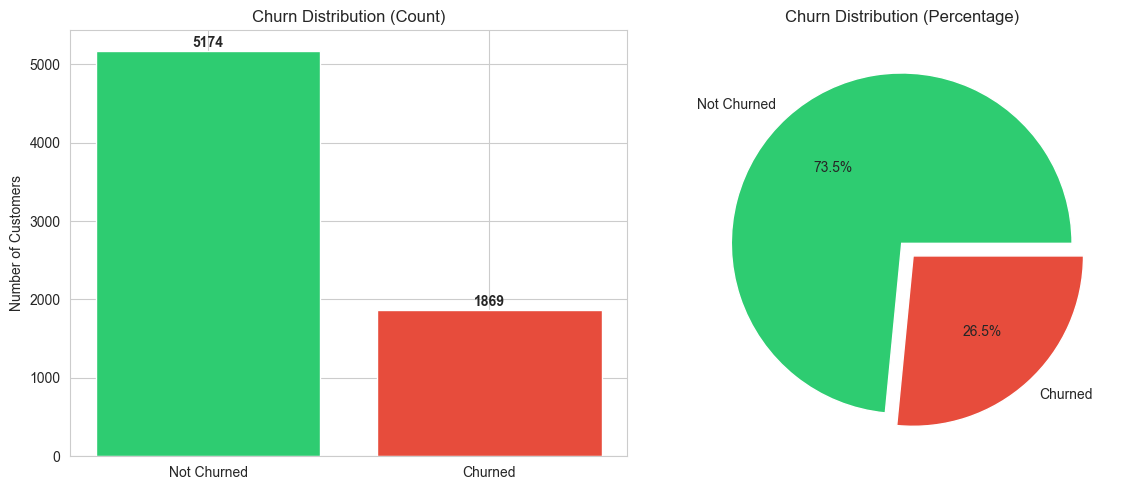

In [7]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].mean() * 100

print('Target Variable Distribution:')
print('=' * 50)
print(f'Not Churned (0): {churn_counts[0]} ({100 - churn_rate:.1f}%)')
print(f'Churned (1):     {churn_counts[1]} ({churn_rate:.1f}%)')
print(f'Class Imbalance Ratio: {churn_counts[0] / churn_counts[1]:.2f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Not Churned', 'Churned'], churn_counts.values, color=colors)
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Churn Distribution (Count)')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=colors, explode=(0, 0.1))
axes[1].set_title('Churn Distribution (Percentage)')
plt.tight_layout()
plt.show()

## Numerical Feature Analysis

The dataset has 3 numerical features: `tenure`, `MonthlyCharges`, and `TotalCharges`. `SeniorCitizen` is binary (0/1).

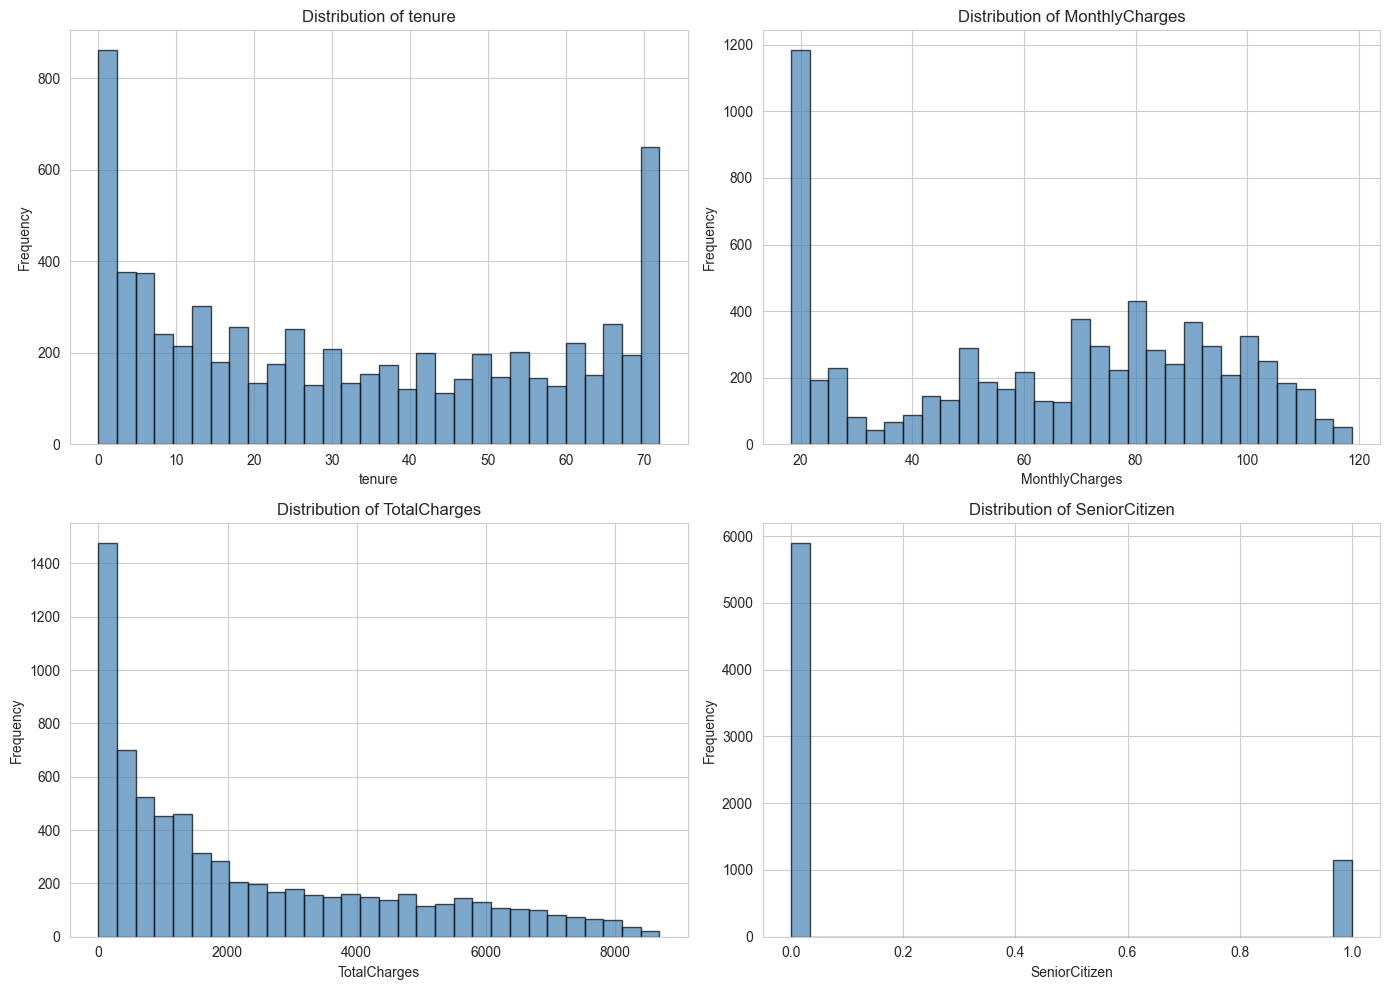

In [8]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    df[col].hist(ax=ax, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

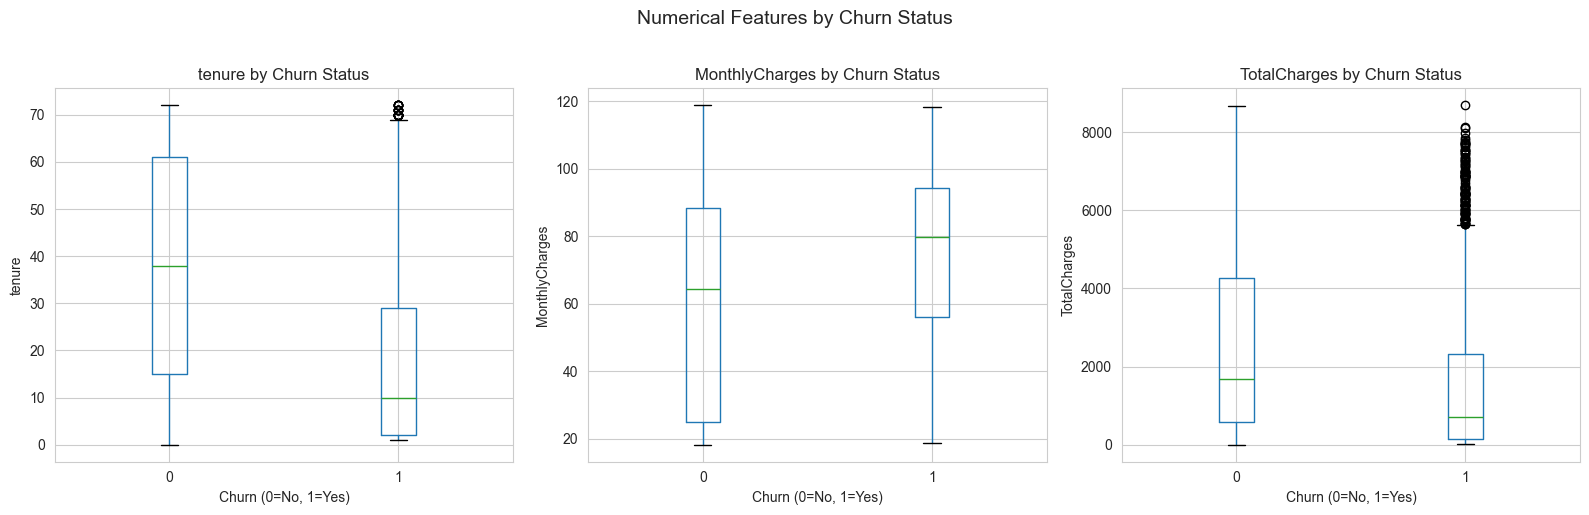

In [9]:
# Numerical features by churn status
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    ax = axes[i]
    df.boxplot(column=col, by='Churn', ax=ax)
    ax.set_xlabel('Churn (0=No, 1=Yes)')
    ax.set_ylabel(col)
    ax.set_title(f'{col} by Churn Status')

plt.suptitle('Numerical Features by Churn Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Key observations from numerical features:

- **Tenure** shows a strong relationship with churn: customers who churn tend to have much shorter tenures. This is the strongest numerical predictor.
- **MonthlyCharges** are higher for churned customers, suggesting that price sensitivity drives churn.
- **TotalCharges** are lower for churned customers, which makes sense since they leave earlier (shorter tenure = less total spend).

## Categorical Feature Analysis

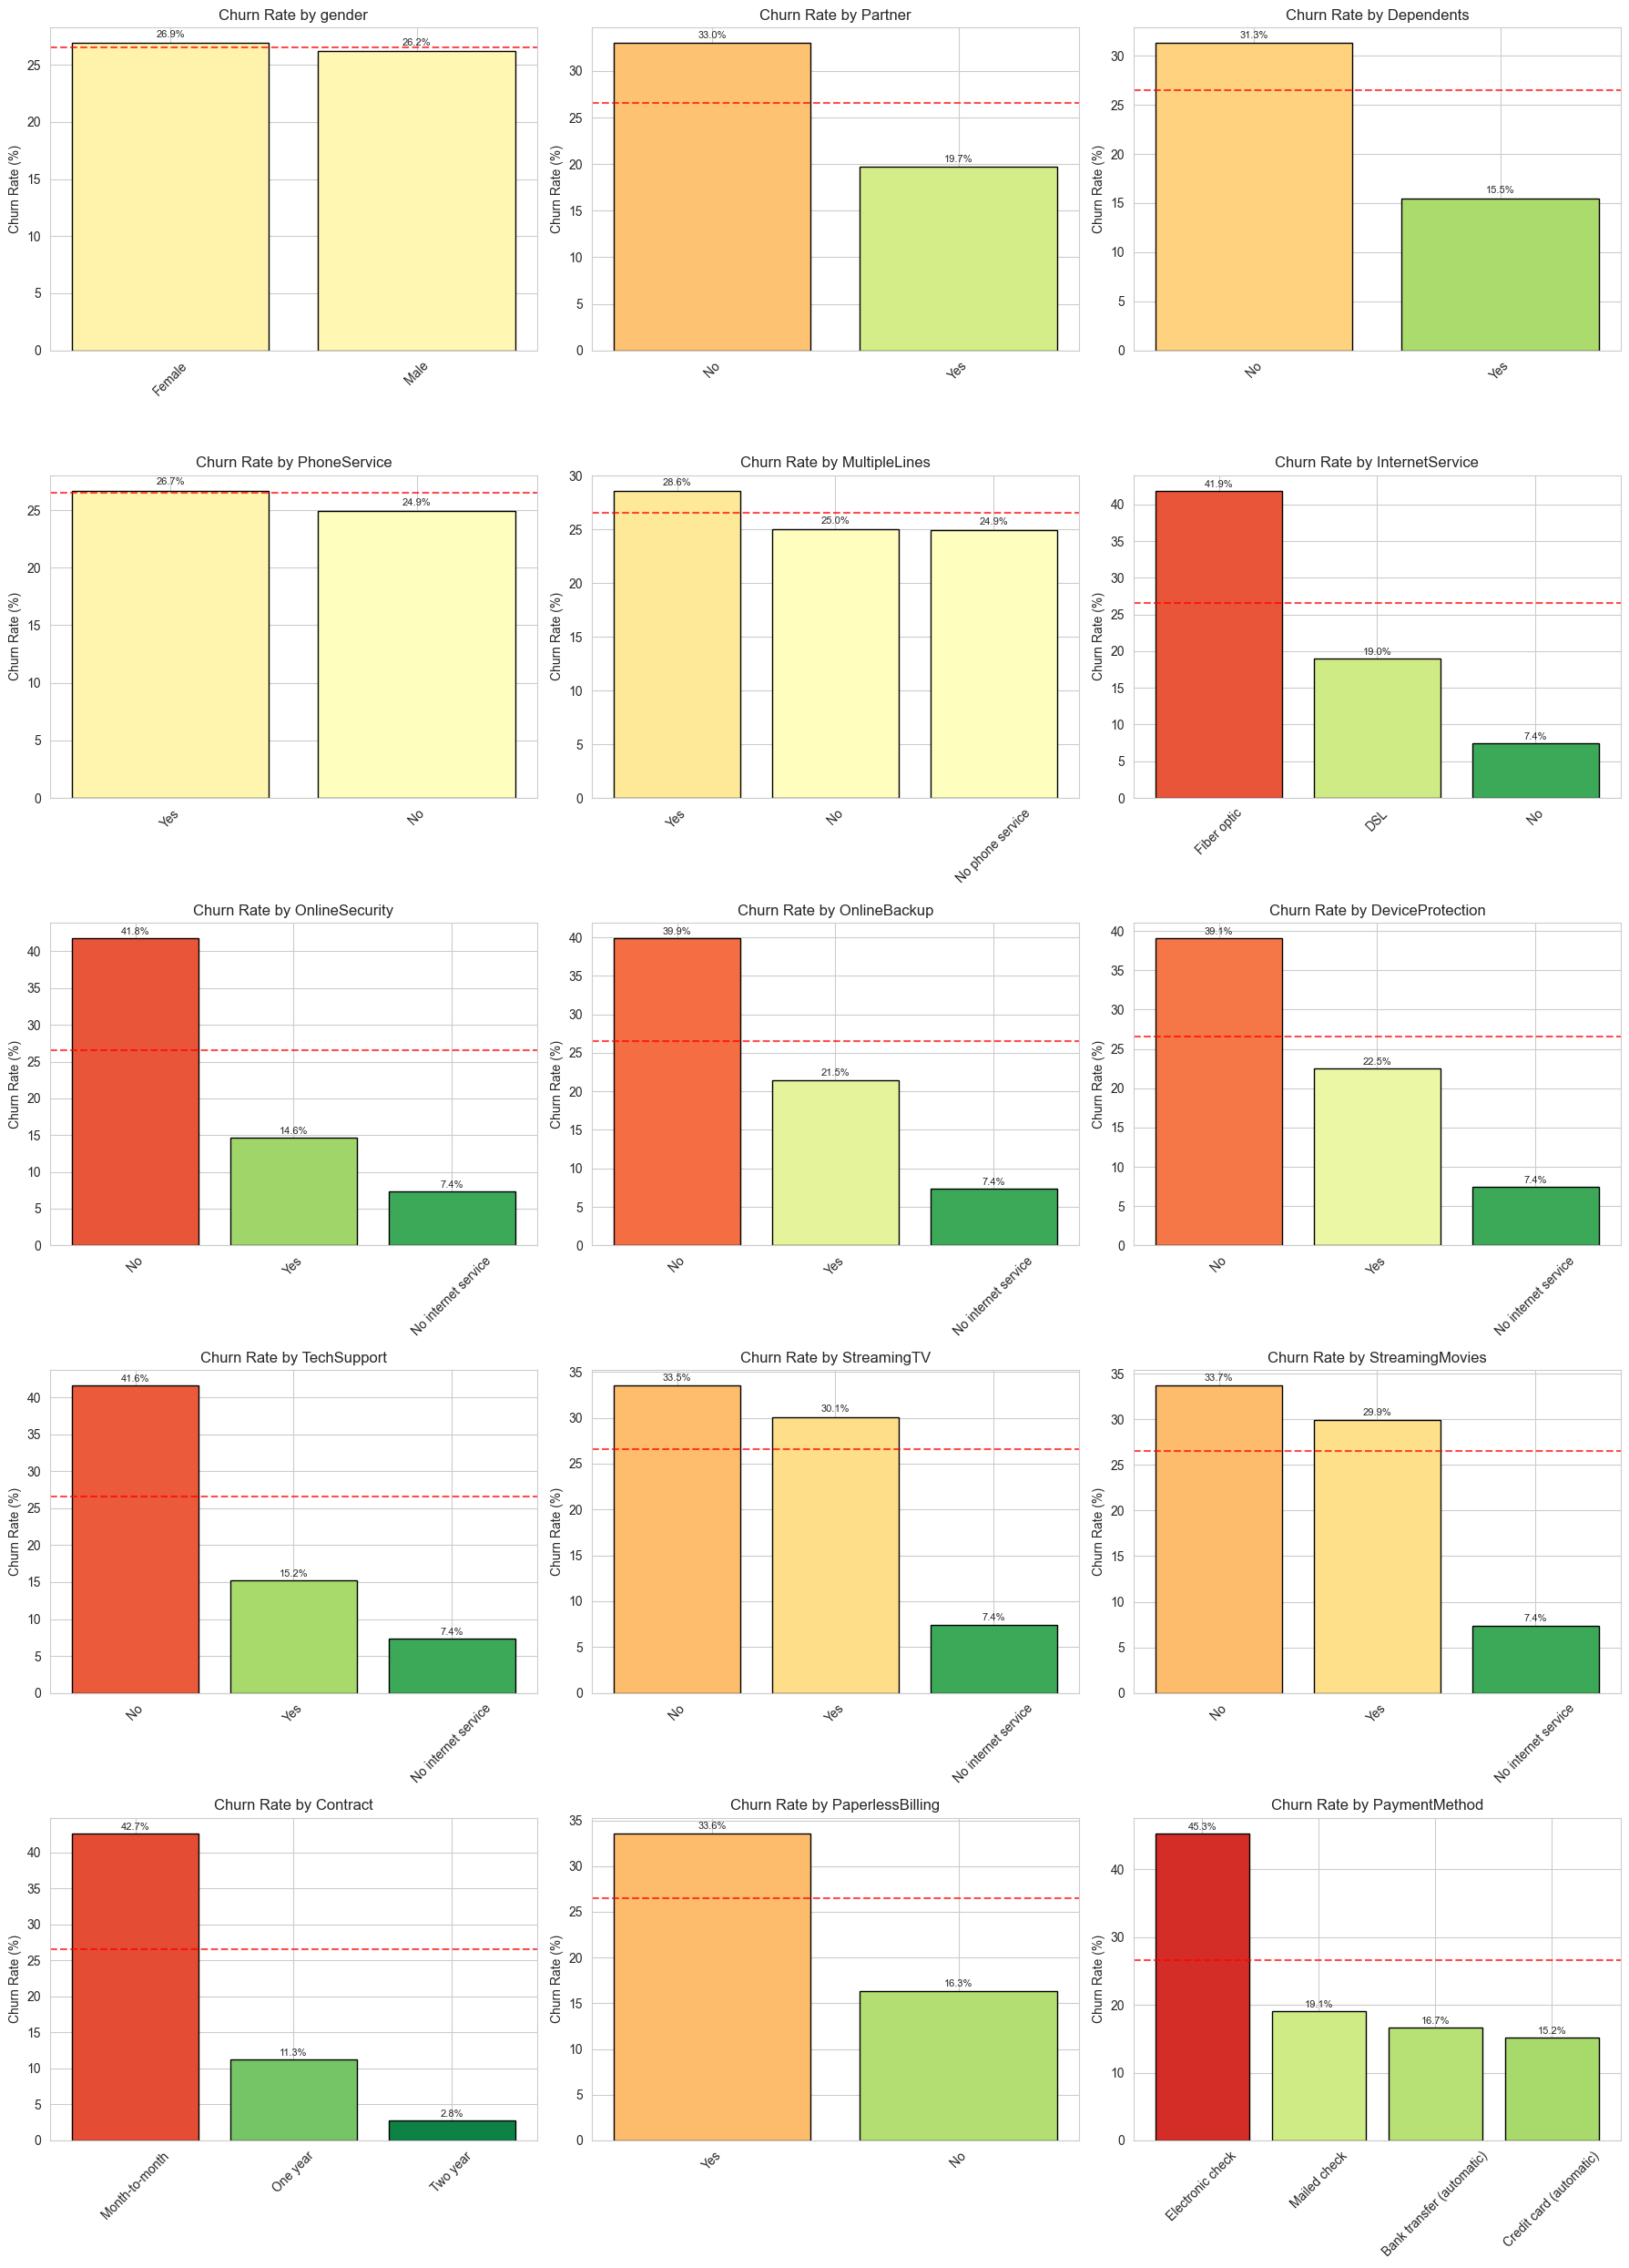

In [10]:
# Churn rate by each categorical feature
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(5, 3, figsize=(18, 25))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    churn_by_cat = df.groupby(col)['Churn'].agg(['mean', 'count'])
    churn_by_cat['churn_rate'] = (churn_by_cat['mean'] * 100).round(1)
    churn_by_cat = churn_by_cat.sort_values('churn_rate', ascending=False)

    colors = plt.cm.RdYlGn_r(churn_by_cat['churn_rate'] / 50)
    bars = ax.bar(churn_by_cat.index, churn_by_cat['churn_rate'], color=colors, edgecolor='black')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_title(f'Churn Rate by {col}')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(y=churn_rate, color='red', linestyle='--', alpha=0.7)
    for bar, rate in zip(bars, churn_by_cat['churn_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{rate}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

Key observations from categorical features:

- **Contract type** is the strongest categorical predictor: month-to-month contracts have ~42.7% churn vs ~2.8% for two-year contracts.
- **Internet service type** matters: Fiber optic customers churn at ~41.9% vs ~19% for DSL and ~7.4% for no internet.
- **Online Security, Tech Support, Online Backup, Device Protection** — customers without these services churn at much higher rates.
- **Payment method**: Electronic check users churn significantly more than others.
- **Gender** shows no meaningful difference in churn rates.

## Correlation Analysis

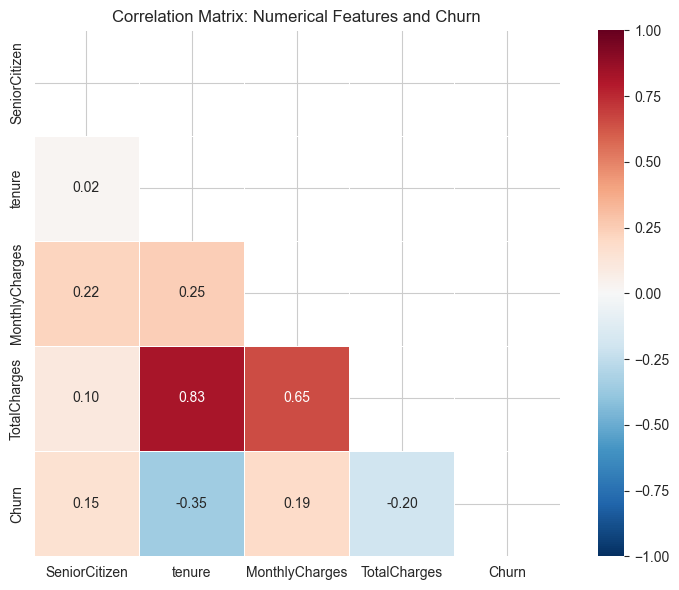


Correlation with Churn:
  tenure              : -0.3522 (higher value decreases churn)
  TotalCharges        : -0.1983 (higher value decreases churn)
  MonthlyCharges      : +0.1934 (higher value increases churn)
  SeniorCitizen       : +0.1509 (higher value increases churn)


In [11]:
# Correlation of numerical features with Churn
corr_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
correlation_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Correlation Matrix: Numerical Features and Churn')
plt.tight_layout()
plt.show()

print('\nCorrelation with Churn:')
churn_corr = correlation_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
for feat, corr in churn_corr.items():
    direction = 'increases' if corr > 0 else 'decreases'
    print(f'  {feat:20}: {corr:+.4f} (higher value {direction} churn)')

The correlation analysis reveals meaningful relationships with churn:

- **Tenure** has the strongest correlation (-0.35): longer-tenured customers are much less likely to churn.
- **MonthlyCharges** (+0.19): higher monthly bills correlate with higher churn.
- **TotalCharges** (-0.20): lower total spend correlates with churn (because they leave early).
- **SeniorCitizen** (+0.15): senior citizens are somewhat more likely to churn.

Unlike the previous synthetic dataset where all correlations were near zero, this dataset has clear, interpretable feature-target relationships.

## Summary

The Telco Customer Churn dataset has 7,043 customers with a 26.5% churn rate (imbalanced, ~2.8:1 ratio).

**Strongest predictors of churn:**
1. **Contract type** — month-to-month customers churn at 42.7% vs 2.8% for two-year contracts
2. **Tenure** — shorter tenure strongly predicts churn (correlation: -0.35)
3. **Internet service** — fiber optic customers churn at 41.9%
4. **Lack of add-on services** — no online security, tech support, etc. increases churn
5. **Monthly charges** — higher charges increase churn
6. **Payment method** — electronic check users churn more

**Next steps:**
- Encode categorical variables
- Handle class imbalance (class weights)
- Train models and compare against baseline

## Data Preparation

Split into train/validation/test (60/20/20) for modeling.

In [12]:
from sklearn.model_selection import train_test_split

# All features except Churn (customerID already dropped)
feature_cols = [c for c in df.columns if c != 'Churn']

X = df[feature_cols].copy()
y = df['Churn'].copy()

# 80/20 split, then 60/20 from the 80
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print('Dataset Split Summary:')
print('=' * 50)
for name, xs, ys in [('Train', X_train, y_train), ('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    print(f'  {name:12}: {len(xs):5} samples ({len(xs)/len(X)*100:.1f}%) — {ys.mean()*100:.1f}% churn')

Dataset Split Summary:
  Train       :  4225 samples (60.0%) — 26.5% churn
  Validation  :  1409 samples (20.0%) — 26.5% churn
  Test        :  1409 samples (20.0%) — 26.5% churn


In [13]:
# Save cleaned dataset locally and as sample for deliverable
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
os.makedirs(data_dir, exist_ok=True)

df.to_csv(os.path.join(data_dir, 'telco_customer_churn.csv'), index=False)
print(f'Full dataset saved to data/telco_customer_churn.csv')

# Stratified sample for deliverable
sample = df.groupby('Churn', group_keys=False).apply(
    lambda x: x.sample(n=int(1000 * len(x) / len(df)), random_state=42)
)
sample.to_csv(os.path.join(data_dir, 'dataset_sample.csv'), index=False)
print(f'Sample ({len(sample)} rows) saved to data/dataset_sample.csv')

Full dataset saved to data/telco_customer_churn.csv
Sample (999 rows) saved to data/dataset_sample.csv


## Baseline Model

The baseline predicts the majority class (no churn) for every customer.

In [14]:
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
from baseline import BaselineModel, print_metrics

baseline = BaselineModel()
baseline.fit(X_train, y_train)
print(f'Model: {baseline}')
print(f'Class distribution: {baseline.class_distribution}')

train_metrics = baseline.evaluate(X_train, y_train)
print_metrics(train_metrics, 'Training Set')

val_metrics = baseline.evaluate(X_val, y_val)
print_metrics(val_metrics, 'Validation Set')

Model: BaselineModel(predicts=0)
Class distribution: {np.int64(0): np.int64(3104), np.int64(1): np.int64(1121)}

Training Set Metrics:
-----------------------------------
Accuracy:  0.7347
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.5000

Confusion Matrix:
[[3104    0]
 [1121    0]]

Validation Set Metrics:
-----------------------------------
Accuracy:  0.7346
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.5000

Confusion Matrix:
[[1035    0]
 [ 374    0]]


The baseline achieves ~73.5% accuracy by always predicting "no churn" (since 73.5% of customers don't churn). But it has 0 recall — it never identifies any churner. ROC-AUC of 0.50 confirms it performs no better than random guessing.

Any real model needs to beat ROC-AUC 0.50 and achieve meaningful recall.